   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

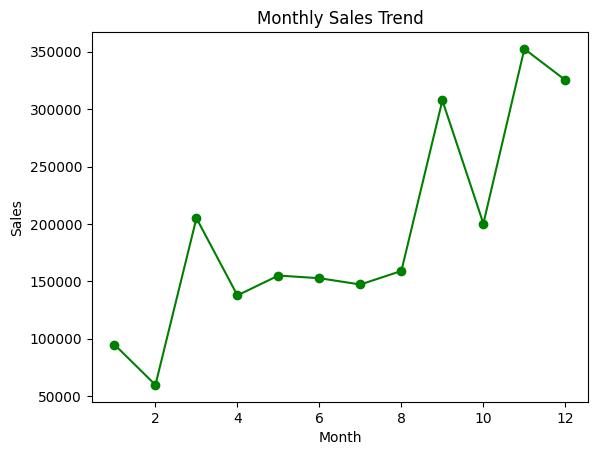

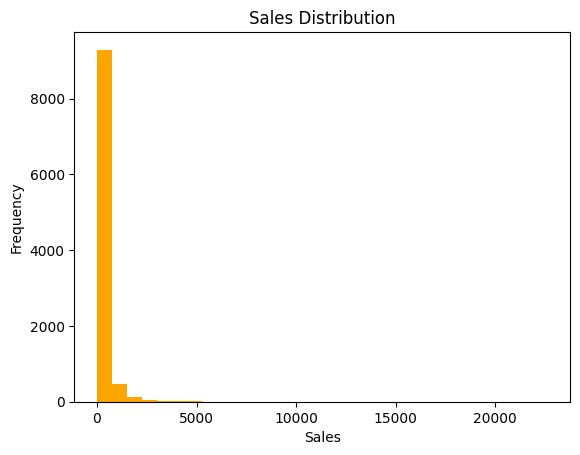

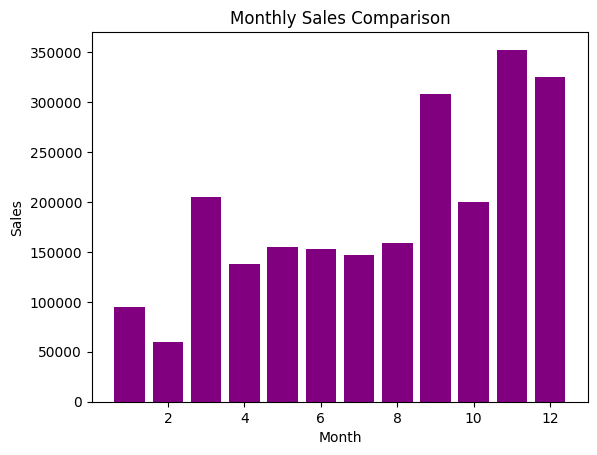

MAE: 260.84965679728606
MSE: 343018.4060634522


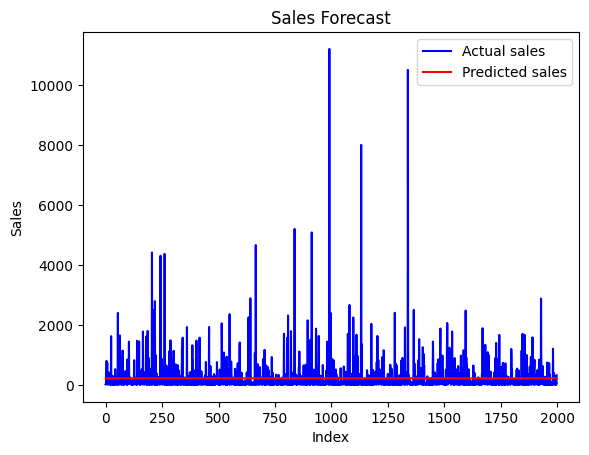


Future Predictions:
2017-12-31 -> 217.03
2018-01-31 -> 211.97
2018-02-28 -> 211.83
2018-03-31 -> 211.7
2018-04-30 -> 211.56
2018-05-31 -> 211.42


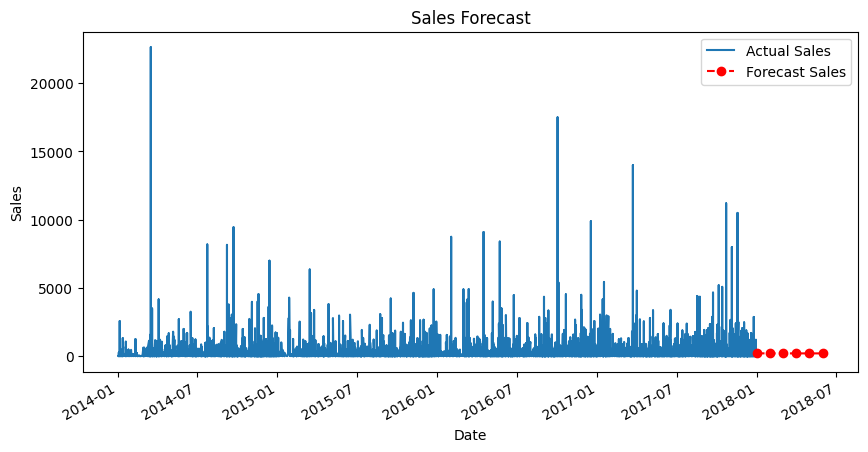

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 🔹 Load dataset
df = pd.read_csv("super.csv", encoding='latin1')

print(df.head())

# 🔹 Convert and rename columns
df['Order Date'] = pd.to_datetime(df['Order Date'])

df = df.rename(columns={
    'Order Date': 'date',
    'Sales': 'sales'
})

# 🔹 Sort & clean
df = df.sort_values('date')
df = df.dropna()

# create moth column for graphs
df['month']=df['date'].dt.month

#aggregate monthly sales
monthly_sales=df.groupby('month')['sales'].sum().reset_index()
print(monthly_sales.head())

# -------------------------------
# 📊 Graph 1 – Sales Trend (Line Chart)
# -------------------------------
plt.figure()
plt.plot(monthly_sales["month"], monthly_sales["sales"], marker='o',color='green')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

# -------------------------------
# 📊 Graph 2 – Sales Distribution (Histogram)
# -------------------------------
plt.figure()
plt.hist(df["sales"], bins=30,color='orange')
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

# -------------------------------
# 📊 Graph 3 – Sales Comparison (Bar Chart)
# -------------------------------
plt.figure()
plt.bar(monthly_sales["month"], monthly_sales["sales"],color='purple')
plt.title("Monthly Sales Comparison")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()


# 🔹 Time Features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

# 🔹 Features & Target
X = df[['year', 'month', 'day']]
y = df['sales']

# 🔹 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


# 🔹 Train Model (THIS WAS MISSING ❗)
model = LinearRegression()
model.fit(X_train, y_train)

# 🔹 Predictions
y_pred = model.predict(X_test)

# 🔹 Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)

# 🔹 Visualization vs predicted 
plt.figure()
plt.plot(y_test.values, label='Actual sales',color='blue')
plt.plot(y_pred, label='Predicted sales',color='red')
plt.xlabel("Index")
plt.ylabel("Sales")
plt.legend()
plt.title("Sales Forecast")
plt.show()

# 🔹 Future Prediction
future_dates = pd.date_range(start=df['date'].max(), periods=6,freq='ME')

future_df = pd.DataFrame()
future_df['date'] = future_dates

future_df['year'] = future_df['date'].dt.year
future_df['month'] = future_df['date'].dt.month
future_df['day'] = 1

future_predictions = model.predict(future_df[['year', 'month', 'day']])

print("\nFuture Predictions:")
for d, pred in zip(future_dates, future_predictions):
    print(d.date(), "->", round(pred, 2))


# -------------------------------
# 📊 Graph 5 – Future Forecast
# -------------------------------
plt.figure(figsize=(10,5))

plt.plot(df['date'], df['sales'], label="Actual Sales")

plt.plot(future_dates,
         future_predictions,
         linestyle="dashed",
         marker="o",
         color='red',
         label="Forecast Sales")
plt.xticks(rotation=45)
plt.gcf().autofmt_xdate()

plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()